In [5]:
import sqlite3
import pandas as pd

In [6]:
# create database file
conn = sqlite3.connect("analytics.db")

In [7]:
# load data
df = pd.read_csv("sales_data.xls")
df.head()

,order_id,order_date,customer_id,customer_segment,region,country,product_category,product_name,quantity,unit_price,revenue
0,1001,2024-01-05,C001,Consumer,North America,USA,Technology,Laptop,1,1200,1200
1,1002,2024-01-07,C002,Corporate,Europe,Germany,Office Supplies,Printer Paper,10,5,50
2,1003,2024-01-10,C003,Small Business,Europe,UK,Furniture,Office Chair,2,180,360
3,1004,2024-01-12,C004,Consumer,Asia,India,Technology,Smartphone,1,800,800
4,1005,2024-01-15,C001,Consumer,North America,USA,Office Supplies,Notebook,5,4,20


In [8]:
# write the data to sql
df.to_sql(
    name="sales",
    con=conn,
    if_exists="replace",  # overwrite if it exists
    index=False
)

30

In [9]:
# confirm database is working
pd.read_sql(
    "SELECT COUNT(*) AS row_count FROM sales",
    conn
)

,row_count
0,30


In [10]:
# first query

query = """
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC
"""

pd.read_sql(query, conn)

,region,total_revenue
0,North America,6020
1,Asia,5958
2,Europe,5274


In [11]:
# optional but good practice to close the connection after analysis is done
#conn.close()

## Business Questions

### Level 1, Basic Reporting
1. “What is our total revenue so far?”
(Single KPI)

2. “How much revenue did we generate by region?”
(GROUP BY)

3. “Which product categories are generating the most revenue?”

4. “How many orders have we had in total?”

5. “What is the average order value?”

### Level 2, Business Breakdown & Comparison

6. “Show revenue and number of orders by customer segment.”

7. “Which countries are our top 5 revenue contributors?”

8. “What are our best-selling products by total revenue?”

9. “How does revenue differ between Consumer, Corporate, and Small Business customers?”

10. “Which regions sell the most Technology products?”

### Level 3, Time-Based Analysis

11. “What is our total revenue by month?”

12. “How has revenue trended over time?”
(Same as above, but think presentation)

13. “Which month had the highest revenue?”

14. “How many orders do we get each month?”

15. “What is the average order value per month?”

### Level 4, Customer & Product Insights
16. “Who are our top 5 customers by total revenue?”

17. “How much revenue comes from repeat customers vs one-time customers?”

18. “Which products have the highest average selling price?”

19. “What percentage of revenue comes from each product category?”

20. “Which customer segment is the most profitable?”

### Level 5, Advanced / Interview-Style Questions
21. “Rank products within each category by total revenue.”
(Window function mindset)

22. “What is the month-over-month revenue growth?”

23. “Which region experienced the fastest growth over time?”

24. “What share of total revenue does our top 20% of customers generate?”

25. “If we stopped selling Office Supplies, how much revenue would we lose?”

### 1. Total revenue

In [12]:
# make the query to sum up the revenue column

query = """
SELECT
    SUM(revenue) AS total_revenue
FROM sales
"""

pd.read_sql(query, conn)

,total_revenue
0,17252


### Answer:
Our total revenue so far is 17252.

### 2. Revenue by region

In [13]:
# sum up the revenue and group by region

query = """
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC
"""

pd.read_sql(query, conn)

,region,total_revenue
0,North America,6020
1,Asia,5958
2,Europe,5274


### Answer:
The revenue in each region is 6020 in North America, 5958 in Asia and 5274 in Europe.

### 3. Max revenue by product category

In [14]:
# we need to sum the revenue by product category and extract the maximum

query = """
SELECT
    product_category,
    SUM(revenue) AS category_revenue
FROM sales
GROUP BY product_category
ORDER BY category_revenue DESC
LIMIT 1;
"""

pd.read_sql(query, conn)

# LIMIT 1 returns 1 row from the data
# since data is already ordered from high to low, the first row will be the highest (maximum)

,product_category,category_revenue
0,Technology,13480


### Answer:
The technology product category had the most revenue equal to 13480 out of all the product categories.

### 4. Total orders

In [15]:
# count total amount of orders using order IDs

query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM sales
"""

pd.read_sql(query, conn)

,total_orders
0,30


### Answer:
We have had a total of 30 orders.

### 5. Average order value

In [16]:
# total revenue divided by amount of orders

query = """
SELECT
    ROUND(SUM(revenue) * 1.0 / COUNT(DISTINCT order_id), 2) AS average_order_value
FROM sales
"""

pd.read_sql(query, conn)

,average_order_value
0,575.07


### Answer:
The average order value is 575.07.

### 6 Orders and revenue by customer segment

In [17]:
# pick customer segment, number of orders and revenue

query = """
SELECT
    customer_segment,
    SUM(revenue) AS customer_revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM sales
GROUP BY customer_segment
ORDER BY customer_revenue DESC
"""

pd.read_sql(query, conn)

,customer_segment,customer_revenue,total_orders
0,Corporate,6780,8
1,Consumer,6652,14
2,Small Business,3820,8


### 7. Top 5 revenue countries

In [18]:

query = """
SELECT
    country,
    SUM(revenue) AS country_revenue
FROM sales
GROUP BY country
ORDER BY country_revenue DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,country,country_revenue
0,USA,3860
1,China,2400
2,India,1952
3,Germany,1850
4,UK,1534


### Answer:
The top 5 countries contributing to the total revenue are from highest to lowest:
USA, China, India, Germany and UK.

### 8. Best-selling products by total revenue

In [19]:
# Calculate the total revenue of each product and rank them from highest to lowest revenue

query = """
SELECT
    product_name,
    SUM(revenue) AS product_revenue
FROM sales
GROUP BY product_name
ORDER BY product_revenue DESC
LIMIT 3
"""

pd.read_sql(query, conn)

,product_name,product_revenue
0,Laptop,5800
1,Monitor,2680
2,Smartphone,2450


### Answer:
The top 3 products with the highest revenue from highest to lowest are Laptop, Monitor, and Smartphone.

### 9. Revenue differentiation between customer segments

In [20]:
# Let's calculate both absolute difference and relative difference, with corporate as the reference (highest revenue)

query = """
WITH revenue_by_segment AS (
    SELECT customer_segment, SUM(revenue) AS total_revenue
    FROM sales
    GROUP BY customer_segment
)
SELECT
    ABS(
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Corporate')
      -
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Consumer')
    ) AS corporate_consumer_diff,
    
    ABS(
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Corporate')
      -
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Small Business')
    ) AS corporate_business_diff,
    
    ABS(
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Consumer')
      -
      (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Small Business')
    ) AS consumer_business_diff,
    
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Consumer') * 1.0 /
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Corporate') AS consumer_to_corporate_ratio,
    
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Small Business') * 1.0 /
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Corporate') AS business_to_corporate_ratio,
    
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Small Business') * 1.0 /
    (SELECT total_revenue FROM revenue_by_segment WHERE customer_segment = 'Consumer') AS business_to_consumer_ratio;
"""

pd.read_sql(query, conn)

,corporate_consumer_diff,corporate_business_diff,consumer_business_diff,consumer_to_corporate_ratio,business_to_corporate_ratio,business_to_consumer_ratio
0,128,2960,2832,0.981121,0.563422,0.574263


### Answer:

Corporate customers lead in revenue, generating significantly more than both Consumer and Small Business segments.

- The revenue difference between Corporate and Consumer is 128, indicating Consumer revenue is nearly equal to Corporate revenue, at about 98%.
- Small Business revenue trails notably, with differences of 2,960 compared to Corporate and 2,832 compared to Consumer.
- In relative terms, Small Business revenue is approximately 56% of Corporate revenue and 57% of Consumer revenue.

This highlights that while Consumer and Corporate segments are close in performance, Small Business contributes considerably less to overall revenue.

### 10. Top 3 regions with most technology products sold

In [21]:
# sample regions, technology products, count quantities, and sort by regions and order from high to low

query = """
SELECT
    region,
    SUM(quantity) AS total_technology_products
FROM sales
WHERE product_category = 'Technology'
GROUP BY region
ORDER BY total_technology_products DESC
"""

pd.read_sql(query, conn)

,region,total_technology_products
0,Asia,9
1,North America,8
2,Europe,5


### Answer:
Asia is the top technology seller with 9 products sold, followed by North America with 8 products, and last is Europe with 5 products.

### 11. Total revenue by month

In [22]:
# filter revenues by month

query = """
SELECT
    strftime('%Y-%m', order_date) AS year_month,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY year_month
ORDER BY year_month
"""

pd.read_sql(query, conn)

,year_month,total_revenue
0,2024-01,2430
1,2024-02,2536
2,2024-03,3572
3,2024-04,3810
4,2024-05,4904


### 12. Total revenue trend over time

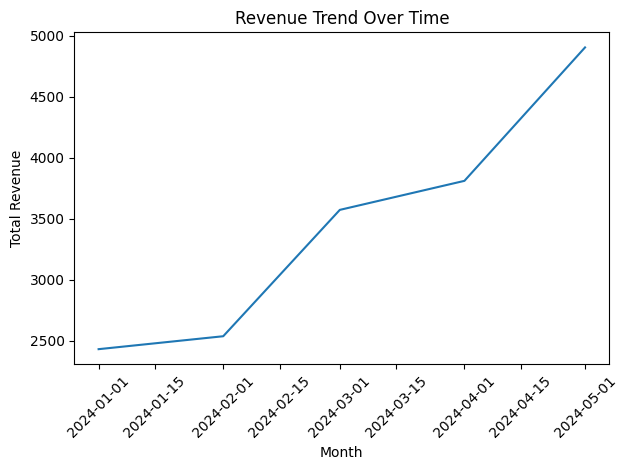

In [23]:
# use same query as before

import matplotlib.pyplot as plt

query = """
SELECT
    strftime('%Y-%m', order_date) AS year_month,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY year_month
ORDER BY year_month
"""

df = pd.read_sql(query, conn)
df['year_month'] = pd.to_datetime(df['year_month'])

plt.plot(df['year_month'], df['total_revenue'])
plt.title('Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 13. Highest revenue month

In [24]:
# same as before, order by high to low revenue and show first row

query = """
SELECT
    strftime('%Y-%m', order_date) AS year_month,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY year_month
ORDER BY total_revenue DESC
LIMIT 1
"""

pd.read_sql(query, conn)

,year_month,total_revenue
0,2024-05,4904


### Answer:
May of 2024 had the highest revenue of 4904.

### 14. Amount of orders per month

In [25]:
# sum together order id and months
# divide orders by months

query = """
SELECT
    strftime('%Y-%m', order_date) AS year_month,
    COUNT(DISTINCT order_id) AS orders_per_month
FROM sales
GROUP BY year_month
ORDER BY year_month
"""

pd.read_sql(query, conn)

,year_month,orders_per_month
0,2024-01,5
1,2024-02,5
2,2024-03,6
3,2024-04,6
4,2024-05,8


### 15. Average order value per month

In [26]:
query = """
SELECT
    strftime('%Y-%m', order_date) AS year_month,
    ROUND(SUM(revenue) * 1.0 / COUNT(DISTINCT order_id), 2) AS avg_order_value
FROM sales
GROUP BY year_month
ORDER BY year_month;
"""

pd.read_sql(query, conn)

,year_month,avg_order_value
0,2024-01,486.00
1,2024-02,507.20
2,2024-03,595.33
3,2024-04,635.00
4,2024-05,613.00


### 16. Top 5 customers by revenue

In [27]:
query = """
SELECT
    customer_id,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY customer_id
ORDER BY total_revenue DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,customer_id,total_revenue
0,C011,2400
1,C002,1850
2,C003,1534
3,C005,1410
4,C001,1410


### 17. Revenue from repeat customers vs one-time customers

In [28]:
query = """
WITH customer_order_counts AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count,
        SUM(revenue) AS total_revenue
    FROM sales
    GROUP BY customer_id
)
SELECT
    CASE
        WHEN order_count > 1 THEN 'Repeat Customer'
        ELSE 'One-Time Customer'
    END AS customer_type,
    SUM(total_revenue) AS revenue
FROM customer_order_counts
GROUP BY customer_type;
"""

pd.read_sql(query, conn)

,customer_type,revenue
0,One-Time Customer,3370
1,Repeat Customer,13882


### 18. Highest avg selling price per products

In [29]:
query = """
SELECT
    product_name,
    SUM(revenue) / SUM(quantity) AS avg_product_selling_price
FROM sales
GROUP BY product_name
ORDER BY avg_product_selling_price DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,product_name,avg_product_selling_price
0,Conference Table,1200
1,Laptop,1160
2,Smartphone,816
3,Tablet,616
4,Office Desk,500


### 19. Product category as percentage of total revenue

In [42]:
query = """
SELECT
    product_category,
    SUM(revenue) AS category_revenue,
    SUM(revenue) * 1.0 / SUM(SUM(revenue)) OVER () AS pct_of_total_revenue
FROM sales
GROUP BY product_category
"""

pd.read_sql(query, conn)

,product_category,category_revenue,pct_of_total_revenue
0,Furniture,3280,0.190123
1,Office Supplies,492,0.028518
2,Technology,13480,0.781359


### Answer:
Technology made up the biggest portion as 78% of total revenue, with Furniture as 19% and Office Supplies as 3% of total revenue.

### 20. Most profitable customer segment

In [50]:
# for this we just compute the customer segment with highest revenue

query = """
SELECT
    customer_segment,
    SUM(revenue) AS customer_revenue,
    SUM(revenue) * 1.0 / SUM(SUM(revenue)) OVER () AS pct_of_total_revenue
FROM sales
GROUP BY customer_segment
ORDER BY customer_revenue DESC
"""

pd.read_sql(query, conn)

,customer_segment,customer_revenue,pct_of_total_revenue
0,Corporate,6780,0.392998
1,Consumer,6652,0.385578
2,Small Business,3820,0.221424


### Answer:
Corporate is the most profitable customer segment with 6780 revenue, which makes up 39% of the total revenue.

### 21. Rank products within each category by total revenue

In [59]:
# so we need to select category, and the product names

query = """
SELECT
    product_category,
    product_name,
    SUM(revenue) AS product_revenue,
    RANK() OVER (
    PARTITION BY product_category
    ORDER BY SUM(revenue) DESC
) AS rank_in_category
FROM sales
GROUP BY product_category, product_name
ORDER BY product_revenue DESC
"""

pd.read_sql(query, conn)

,product_category,product_name,product_revenue,rank_in_category
0,Technology,Laptop,5800,1
1,Technology,Monitor,2680,2
2,Technology,Smartphone,2450,3
3,Technology,Tablet,1850,4
4,Furniture,Conference Table,1200,1
5,Furniture,Office Chair,550,2
6,Furniture,Bookshelf,520,3
7,Furniture,Office Desk,500,4
8,Furniture,Desk,450,5
9,Technology,Printer,400,5


### 22. Month-by-month revenue growth

In [63]:
# calculate revenue for each month
# define growth as the percentage difference of month_i - month_(i-1) / month_(i-1)

query = """
WITH monthly_revenue AS (
    SELECT
        strftime('%Y-%m', order_date) AS year_month,
        SUM(revenue) AS revenue
    FROM sales
    GROUP BY year_month
)
SELECT
    year_month,
    revenue,
    LAG(revenue) OVER (ORDER BY year_month) AS prev_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY year_month)) * 1.0 / LAG(revenue) OVER (ORDER BY year_month),
        3
    ) AS mom_growth
FROM monthly_revenue
ORDER BY year_month;
"""

pd.read_sql(query, conn)


,year_month,revenue,prev_revenue,mom_growth
0,2024-01,2430,NaN,NaN
1,2024-02,2536,2430.0,0.044
2,2024-03,3572,2536.0,0.409
3,2024-04,3810,3572.0,0.067
4,2024-05,4904,3810.0,0.287


### Q23. Region with fastest growth over time

In [70]:
query = """
WITH monthly_revenue AS (
    SELECT
        region,
        strftime('%Y-%m', order_date) AS year_month,
        SUM(revenue) AS revenue
    FROM sales
    GROUP BY region, year_month
),
mom_growths AS (
    SELECT
        region,
        year_month,
        revenue,
        LAG(revenue) OVER (PARTITION BY region ORDER BY year_month) AS prev_revenue,
        (revenue - LAG(revenue) OVER (PARTITION BY region ORDER BY year_month)) * 1.0 /
        LAG(revenue) OVER (PARTITION BY region ORDER BY year_month) AS mom_growth
    FROM monthly_revenue
)
SELECT
    region,
    ROUND(AVG(mom_growth), 4) AS avg_mom_growth
FROM mom_growths
WHERE prev_revenue IS NOT NULL
GROUP BY region
ORDER BY avg_mom_growth DESC;
"""


pd.read_sql(query, conn)


,region,avg_mom_growth
0,Asia,6.3683
1,Europe,3.5558
2,North America,0.3896


### Answer:
Asia is the region with the fastest growth over time, with an average month-on-month growth of 6.3%.

### Q24. Share of total revenue by top 20% customers

In [72]:
# Steps:
# 1. Calculate total revenue per customer.
# 2. Rank customers by revenue descending.
# 3. Determine the number of customers representing the top 20% (e.g., total customers * 0.2).
# 4. Sum revenue for just those top 20% customers.
# 5. Divide by total revenue to get their share.

query = """
WITH customer_revenue AS (
    SELECT
        customer_id,
        SUM(revenue) AS total_revenue
    FROM sales
    GROUP BY customer_id
),
ranked_customers AS (
    SELECT
        customer_id,
        total_revenue,
        ROW_NUMBER() OVER (ORDER BY total_revenue DESC) AS rn,
        COUNT(*) OVER () AS total_customers
    FROM customer_revenue
),
top_20_percent AS (
    SELECT
        total_revenue
    FROM ranked_customers
    WHERE rn <= total_customers * 0.2
),
total_revenue_all AS (
    SELECT SUM(total_revenue) AS total_revenue FROM customer_revenue
)
SELECT
    ROUND(SUM(total_revenue) * 1.0 / (SELECT total_revenue FROM total_revenue_all), 4) AS top_20_pct_revenue_share
FROM top_20_percent;
"""

pd.read_sql(query, conn)

,top_20_pct_revenue_share
0,0.3353


### Answer:
The top 20% of our customers generate 33% of the total revenue.

### Q25. Revenue lost by stopping Office Supplies

In [76]:
query = """
WITH total_revenue AS (
    SELECT SUM(revenue) AS total_rev FROM sales
),
non_office_revenue AS (
    SELECT SUM(revenue) AS non_office_rev FROM sales
    WHERE product_category != 'Office Supplies'
)
SELECT
    ROUND(non_office_rev * 1.0 / total_rev, 2) AS revenue_share_excluding_office_supplies
FROM total_revenue, non_office_revenue;
"""

pd.read_sql(query, conn)

,revenue_share_excluding_office_supplies
0,0.97


### Answer:
If we stopped selling Office Supplies, we would still generate 97% of our current revenue, since Office Supplies only make up 3% of our total revenue.